In [ ]:
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

from numba import cuda

# LOAD FACEBOOK DATASET OR GENERATE SYNTHETIC DATA


print("Dataset not found.")
print("Generating synthetic Facebook-like network...")

np.random.seed(42)

num_nodes = 500
num_edges = 3000

src = np.random.randint(0, num_nodes, num_edges)
dst = np.random.randint(0, num_nodes, num_edges)

mask = src != dst

src = src[mask]
dst = dst[mask]

edges = pd.DataFrame({
    "src": src,
    "dst": dst
})


# BUILD GRAPH


G = nx.Graph()

for _, row in edges.iterrows():
    G.add_edge(int(row["src"]), int(row["dst"]))

num_nodes = G.number_of_nodes()
num_edges = G.number_of_edges()

print("\nGraph Statistics")
print("Nodes :", num_nodes)
print("Edges :", num_edges)



Dataset not found.
Generating synthetic Facebook-like network...

Graph Statistics
Nodes : 500
Edges : 2965


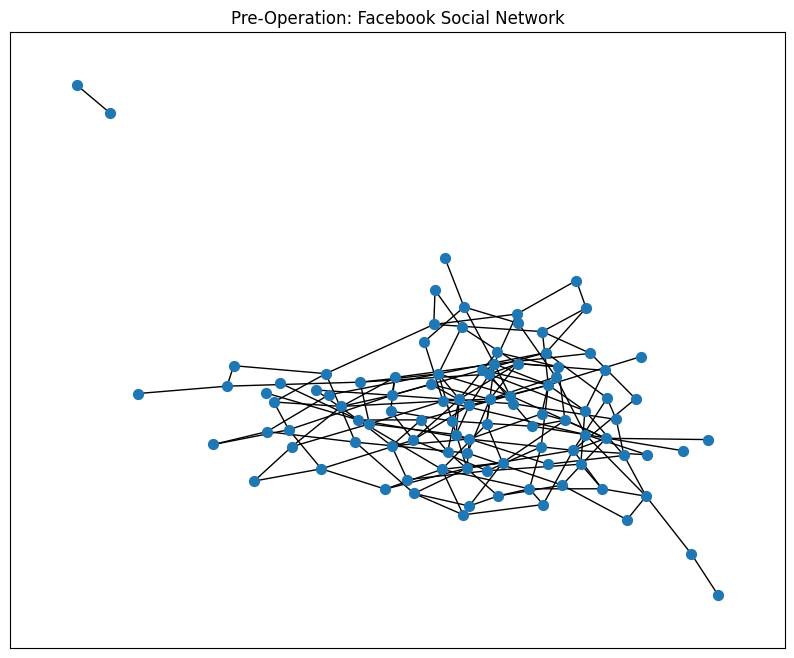

In [ ]:

# PRE-OPERATION VISUALIZATION


sample_nodes = min(100, num_nodes)

sub_nodes = list(G.nodes())[:sample_nodes]
subgraph = G.subgraph(sub_nodes)

plt.figure(figsize=(10,8))
nx.draw_networkx(
    subgraph,
    node_size=50,
    with_labels=False
)
plt.title("Pre-Operation: Facebook Social Network")
plt.show()



In [ ]:

# PREPARE EDGE LIST FOR CUDA


edge_array = np.array(list(G.edges()), dtype=np.int32)

num_edges = edge_array.shape[0]

degrees = np.zeros(num_nodes, dtype=np.int32)



In [ ]:

# CUDA KERNEL


@cuda.jit
def degree_kernel(edges, degrees):

    idx = cuda.grid(1)

    if idx < edges.shape[0]:

        u = edges[idx, 0]
        v = edges[idx, 1]

        cuda.atomic.add(degrees, u, 1)
        cuda.atomic.add(degrees, v, 1)



In [ ]:

# COPY TO GPU


d_edges = cuda.to_device(edge_array)
d_degrees = cuda.to_device(degrees)

threads_per_block = 256
blocks_per_grid = (num_edges + threads_per_block - 1) // threads_per_block


# EXECUTE CUDA KERNEL


degree_kernel[blocks_per_grid, threads_per_block](
    d_edges,
    d_degrees
)

cuda.synchronize()

degrees = d_degrees.copy_to_host()



/usr/local/lib/python3.12/dist-packages/numba_cuda/numba/cuda/dispatcher.py:696: NumbaPerformanceWarning: Grid size 12 will likely result in GPU under-utilization due to low occupancy.
  warn(errors.NumbaPerformanceWarning(msg))



Sample Degree Computation
Node   0 --> Degree = 15
Node   1 --> Degree = 12
Node   2 --> Degree = 13
Node   3 --> Degree = 12
Node   4 --> Degree = 17
Node   5 --> Degree = 6
Node   6 --> Degree = 13
Node   7 --> Degree = 17
Node   8 --> Degree = 10
Node   9 --> Degree = 12
Node  10 --> Degree = 9
Node  11 --> Degree = 20
Node  12 --> Degree = 14
Node  13 --> Degree = 16
Node  14 --> Degree = 9
Node  15 --> Degree = 9
Node  16 --> Degree = 14
Node  17 --> Degree = 4
Node  18 --> Degree = 12
Node  19 --> Degree = 14


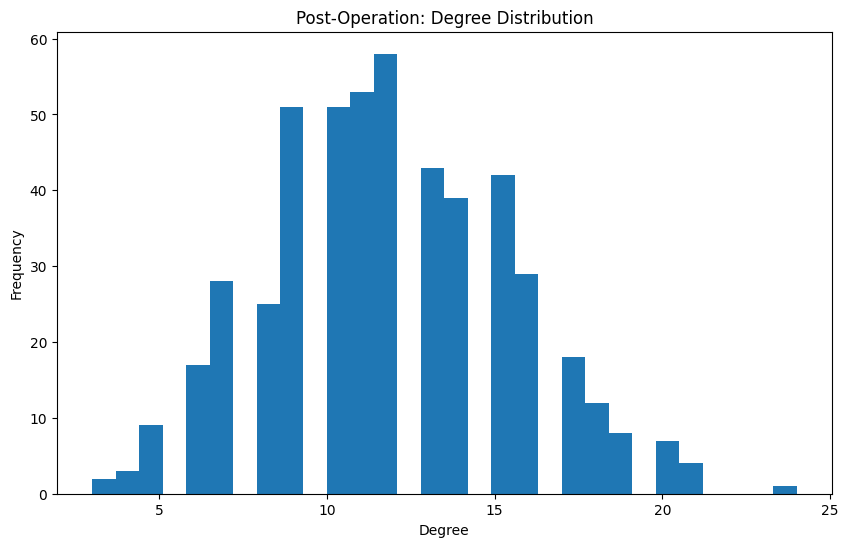

In [ ]:

# DISPLAY SAMPLE OUTPUT


print("\nSample Degree Computation")

for node in range(min(20, num_nodes)):
    print(
        f"Node {node:3d} --> Degree = {degrees[node]}"
    )


# POST-OPERATION VISUALIZATION


plt.figure(figsize=(10,6))

plt.hist(
    degrees,
    bins=30
)

plt.xlabel("Degree")
plt.ylabel("Frequency")
plt.title("Post-Operation: Degree Distribution")
plt.show()




Top 10 High Degree Nodes
Node  153 --> Degree 24
Node  475 --> Degree 21
Node  146 --> Degree 21
Node   38 --> Degree 21
Node  263 --> Degree 21
Node  499 --> Degree 20
Node  172 --> Degree 20
Node  312 --> Degree 20
Node   11 --> Degree 20
Node  434 --> Degree 20


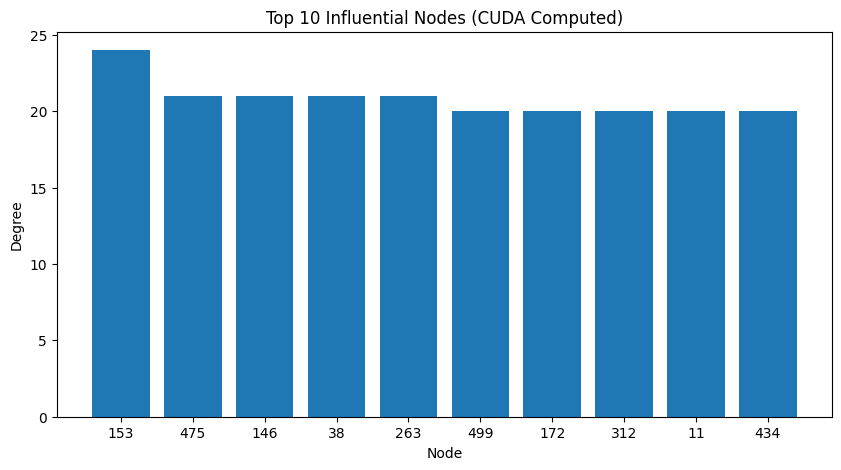

In [ ]:

# TOP NODES


top_nodes = np.argsort(degrees)[::-1][:10]

print("\nTop 10 High Degree Nodes")

for node in top_nodes:
    print(
        f"Node {node:4d} --> Degree {degrees[node]}"
    )


# BAR CHART OF TOP NODES


plt.figure(figsize=(10,5))

plt.bar(
    [str(x) for x in top_nodes],
    degrees[top_nodes]
)

plt.xlabel("Node")
plt.ylabel("Degree")
plt.title("Top 10 Influential Nodes (CUDA Computed)")
plt.show()


GRAPH DEGREE COMPUTATION STATISTICS
Total Nodes            : 500
Total Degree Count     : 5930
Average Degree         : 11.86
Median Degree          : 12.00
Maximum Degree         : 24
Minimum Degree         : 3
Degree Std Deviation   : 3.59

Most Connected Node
Node ID                : 153
Degree                 : 24

Least Connected Node
Node ID                : 70
Degree                 : 3

Degree Percentiles
25th Percentile        : 9.00
50th Percentile        : 12.00
75th Percentile        : 14.00
90th Percentile        : 16.10
95th Percentile        : 18.00
99th Percentile        : 20.01

Node Degree Categories
Isolated Nodes (0)     : 0
Low Degree (1-5)       : 14
Medium Degree (6-20)   : 481
High Degree (>20)      : 5

Top 20 Nodes by Degree
 Node_ID  Degree
     153      24
      38      21
     475      21
     263      21
     146      21
     499      20
     434      20
     112      20
     187      20
      11      20
     312      20
     172      20
      46      19


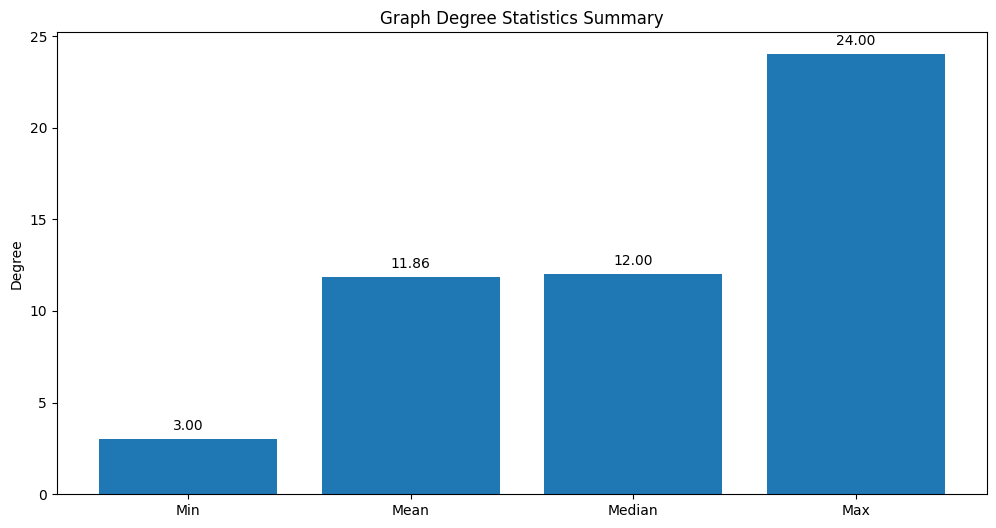


Degree statistics saved to:
social_network_degree_statistics.csv


In [ ]:

# DEGREE STATISTICS OF SOCIAL NETWORK


print("\n" + "="*60)
print("GRAPH DEGREE COMPUTATION STATISTICS")
print("="*60)

# Basic Statistics
total_nodes = len(degrees)
total_degree = np.sum(degrees)
avg_degree = np.mean(degrees)
median_degree = np.median(degrees)
max_degree = np.max(degrees)
min_degree = np.min(degrees)
std_degree = np.std(degrees)

print(f"Total Nodes            : {total_nodes}")
print(f"Total Degree Count     : {total_degree}")
print(f"Average Degree         : {avg_degree:.2f}")
print(f"Median Degree          : {median_degree:.2f}")
print(f"Maximum Degree         : {max_degree}")
print(f"Minimum Degree         : {min_degree}")
print(f"Degree Std Deviation   : {std_degree:.2f}")

# Identify important nodes
highest_degree_node = np.argmax(degrees)
lowest_degree_node = np.argmin(degrees)

print("\nMost Connected Node")
print(f"Node ID                : {highest_degree_node}")
print(f"Degree                 : {degrees[highest_degree_node]}")

print("\nLeast Connected Node")
print(f"Node ID                : {lowest_degree_node}")
print(f"Degree                 : {degrees[lowest_degree_node]}")

# Percentiles
print("\nDegree Percentiles")
print(f"25th Percentile        : {np.percentile(degrees,25):.2f}")
print(f"50th Percentile        : {np.percentile(degrees,50):.2f}")
print(f"75th Percentile        : {np.percentile(degrees,75):.2f}")
print(f"90th Percentile        : {np.percentile(degrees,90):.2f}")
print(f"95th Percentile        : {np.percentile(degrees,95):.2f}")
print(f"99th Percentile        : {np.percentile(degrees,99):.2f}")

# Degree Categories
isolated_nodes = np.sum(degrees == 0)
low_degree_nodes = np.sum((degrees > 0) & (degrees <= 5))
medium_degree_nodes = np.sum((degrees > 5) & (degrees <= 20))
high_degree_nodes = np.sum(degrees > 20)

print("\nNode Degree Categories")
print(f"Isolated Nodes (0)     : {isolated_nodes}")
print(f"Low Degree (1-5)       : {low_degree_nodes}")
print(f"Medium Degree (6-20)   : {medium_degree_nodes}")
print(f"High Degree (>20)      : {high_degree_nodes}")

# Create statistics dataframe
stats_df = pd.DataFrame({
    "Node_ID": np.arange(total_nodes),
    "Degree": degrees
})

print("\nTop 20 Nodes by Degree")
print(stats_df.sort_values(
        by="Degree",
        ascending=False
      ).head(20).to_string(index=False))


# VISUALIZATION OF DEGREE STATISTICS


fig, ax = plt.subplots(figsize=(12,6))

stats_labels = [
    "Min",
    "Mean",
    "Median",
    "Max"
]

stats_values = [
    min_degree,
    avg_degree,
    median_degree,
    max_degree
]

ax.bar(stats_labels, stats_values)

ax.set_title("Graph Degree Statistics Summary")
ax.set_ylabel("Degree")

for i, v in enumerate(stats_values):
    ax.text(i, v + 0.5, f"{v:.2f}", ha='center')

plt.show()


# EXPORT NODE DEGREE TABLE


stats_df.to_csv(
    "social_network_degree_statistics.csv",
    index=False
)

print("\nDegree statistics saved to:")
print("social_network_degree_statistics.csv")